In [2]:
from transformers import AutoProcessor, Gemma3ForConditionalGeneration

model_id = "INSAIT-Institute/BgGPT-Gemma-3-4B-IT"

processor = AutoProcessor.from_pretrained(model_id)
model = Gemma3ForConditionalGeneration.from_pretrained(
    model_id, device_map="auto"
).eval()

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


In [3]:

vocab = processor.tokenizer.get_vocab()

In [4]:
svocab = sorted(vocab.items(), key=lambda x: x[1])

In [5]:
import pandas as pd
pd.Series(svocab).to_csv("vocab.csv", index=False, header=False)

In [6]:
# extract the input embeddings
embeddings= model.model.get_input_embeddings().weight.detach().cpu().float().numpy()
embeddings.shape


(262208, 2560)

In [7]:
import numpy as np
E = embeddings/np.linalg.norm(embeddings, axis=1, keepdims=True)

In [8]:
E.mean(axis=0), E.std(axis=0)

(array([ 6.7039643e-04,  7.9028739e-04, -4.0064242e-05, ...,
        -1.7514750e-03, -1.3587280e-03, -1.2234810e-03],
       shape=(2560,), dtype=float32),
 array([0.01882594, 0.01874775, 0.01897642, ..., 0.01907304, 0.01851049,
        0.01936031], shape=(2560,), dtype=float32))

In [9]:
import seaborn as sns
sns.set_theme()
sns.set_style("white")

In [10]:
from scipy.stats import ortho_group

# generate a random 32x32 orthogonal matrix
def random_rotation(matrix):
    R = ortho_group.rvs(matrix.shape[1])
    return matrix @ R




In [11]:
R = random_rotation(E)

In [12]:
import matplotlib.pyplot as plt

In [13]:
1/2560**0.5

0.01976423537605237

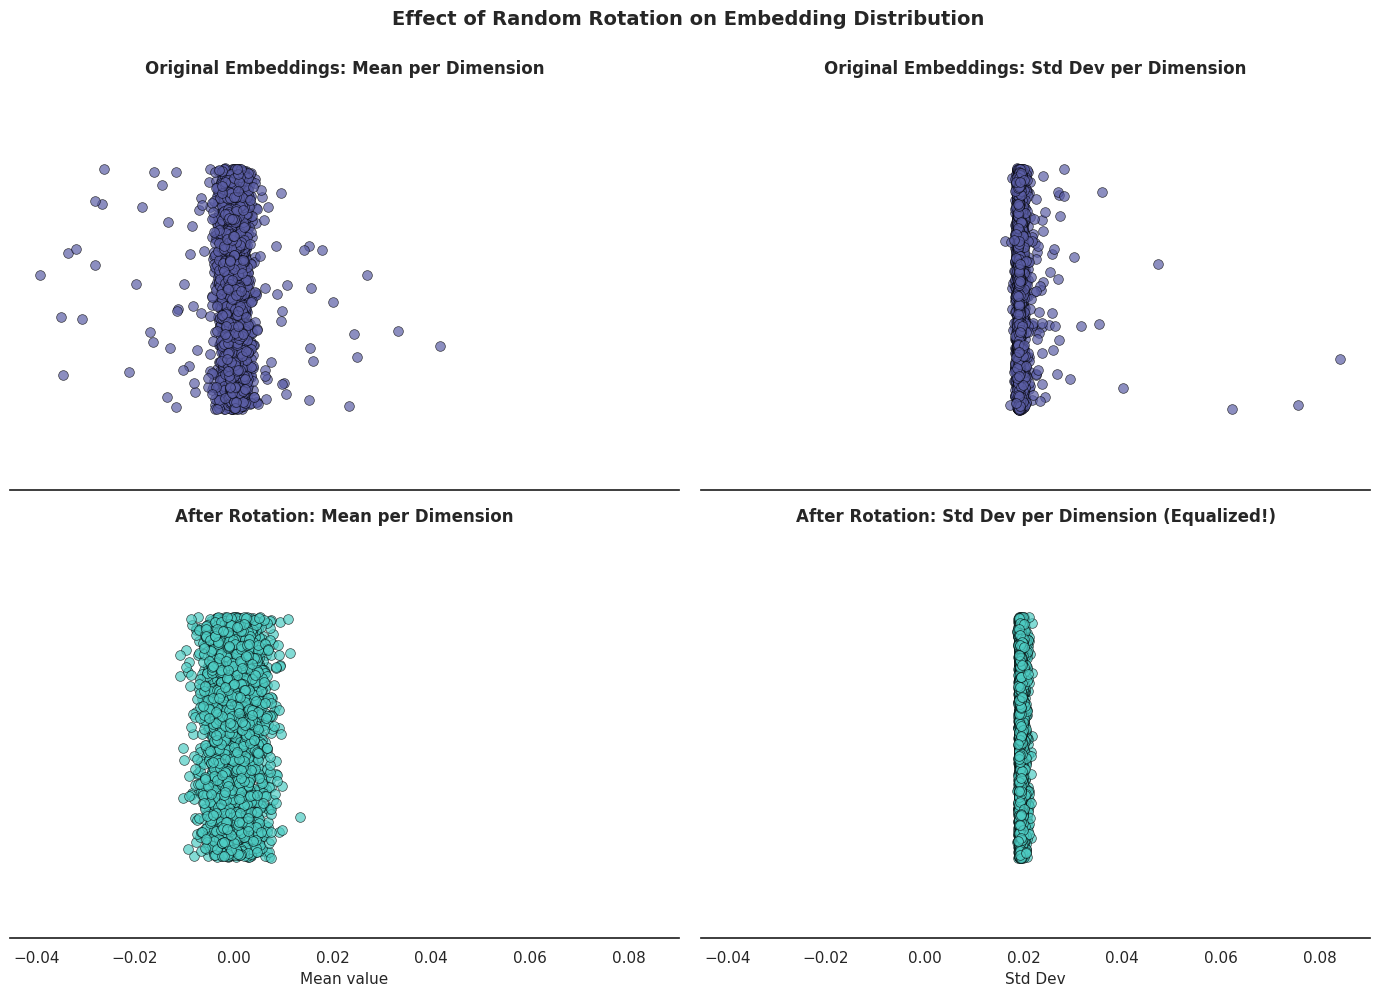

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

# Define colors
original_color = "#5B5EA6"
rotated_color = "#4ECDC4"

# Original means
sns.stripplot(x=E.mean(axis=0), jitter=0.3, size=7, alpha=0.7, ax=ax[0,0], 
              color=original_color, edgecolor="black", linewidth=0.5)
ax[0,0].set_title("Original Embeddings: Mean per Dimension", fontsize=12, fontweight='bold', pad=10)
ax[0,0].set_xlabel("Mean value", fontsize=11)
#ax[0,0].grid(True, alpha=0.3, axis='x')
ax[0,0].set_yticklabels([])

# Original stdev
sns.stripplot(x=E.std(axis=0), jitter=0.3, size=7, alpha=0.7, ax=ax[0,1], 
              color=original_color, edgecolor="black", linewidth=0.5)
ax[0,1].set_title("Original Embeddings: Std Dev per Dimension", fontsize=12, fontweight='bold', pad=10)
ax[0,1].set_xlabel("Std Dev", fontsize=11)
#ax[0,1].grid(True, alpha=0.3, axis='x')
ax[0,1].set_yticklabels([])

# Rotated means
sns.stripplot(x=R.mean(axis=0), jitter=0.3, size=7, alpha=0.7, ax=ax[1,0], 
              color=rotated_color, edgecolor="black", linewidth=0.5)
ax[1,0].set_title("After Rotation: Mean per Dimension", fontsize=12, fontweight='bold', pad=10)
ax[1,0].set_xlabel("Mean value", fontsize=11)
#ax[1,0].grid(True, alpha=0.3, axis='x')
ax[1,0].set_yticklabels([])

# Rotated stdev
sns.stripplot(x=R.std(axis=0), jitter=0.3, size=7, alpha=0.7, ax=ax[1,1], 
              color=rotated_color, edgecolor="black", linewidth=0.5)
ax[1,1].set_title("After Rotation: Std Dev per Dimension (Equalized!)", fontsize=12, fontweight='bold', pad=10)
ax[1,1].set_xlabel("Std Dev", fontsize=11)
#ax[1,1].grid(True, alpha=0.3, axis='x')
ax[1,1].set_yticklabels([])

fig.suptitle("Effect of Random Rotation on Embedding Distribution", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
sns.despine(fig, left=True)

Text(0.5, 0.995, 'Distribution of First 5 Dimensions After Rotation')

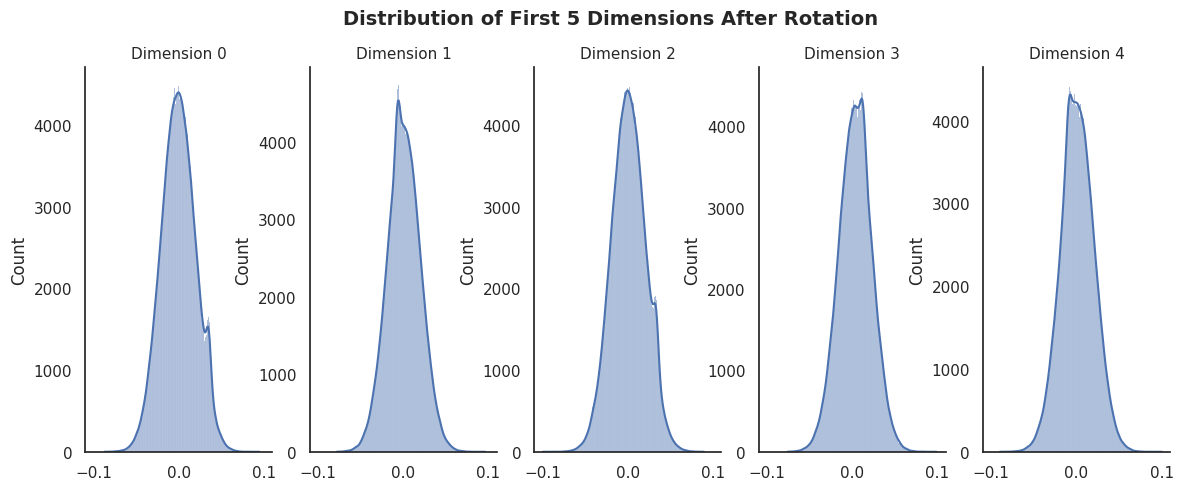

In [24]:
fig, axes = plt.subplots(1, 5, figsize=(14, 5), sharex=True)
for i, ax in enumerate(axes):

    sns.histplot(R[:, i], kde=True,ax=ax)
    sns.despine(ax=ax)
    ax.set_title(f"Dimension {i}", fontsize=11)

fig.suptitle("Distribution of First 5 Dimensions After Rotation", fontsize=14, fontweight='bold', y=0.995)

In [36]:
from scipy.stats import norm

def lloyd_max_gaussian(n_levels, sigma=1.0, max_iter=1000, tol=1e-10):
    """Compute Lloyd-Max quantizer for N(0, sigma^2)."""
    # initialize levels uniformly in [-3sigma, 3sigma]
    levels = np.linspace(-3*sigma, 3*sigma, n_levels)
    
    for _ in range(max_iter):
        # thresholds = midpoints, with -inf and +inf at the ends
        thresholds = np.concatenate([[-np.inf],
                                      (levels[:-1] + levels[1:]) / 2,
                                      [np.inf]])
        # update levels = centroid of truncated Gaussian in each bin
        new_levels = np.empty(n_levels)
        for i in range(n_levels):
            a, b = thresholds[i] / sigma, thresholds[i+1] / sigma
            # E[X | a*sigma < X < b*sigma] = sigma * (phi(a) - phi(b)) / (Phi(b) - Phi(a))
            new_levels[i] = sigma * (norm.pdf(a) - norm.pdf(b)) / (norm.cdf(b) - norm.cdf(a))
        
        if np.max(np.abs(new_levels - levels)) < tol:
            levels = new_levels
            break
        levels = new_levels
    
    thresholds = np.concatenate([[-np.inf],
                                  (levels[:-1] + levels[1:]) / 2,
                                  [np.inf]])
    return thresholds, levels

In [37]:
import math
(2/math.pi)**0.5 / 2560**0.5

0.015769578262626

In [38]:
d = 2560

In [42]:
1.51 / d**0.5

0.029843995417839077

In [40]:
sigma = 1 / np.sqrt(d)

for bits in [1,2,3,4]:
    n_levels = 2**bits
    thresholds, levels = lloyd_max_gaussian(n_levels, sigma=sigma)
    print(f"\n=== {bits}-bit ({n_levels} levels), sigma={sigma:.4f} ===")
    print(f"  Thresholds: {np.round(thresholds[1:-1], 6)}")
    print(f"  Levels:     {np.round(levels, 6)}")


=== 1-bit (2 levels), sigma=0.0198 ===
  Thresholds: [0.]
  Levels:     [-0.01577  0.01577]

=== 2-bit (4 levels), sigma=0.0198 ===
  Thresholds: [-0.019401 -0.        0.019401]
  Levels:     [-0.029852 -0.008949  0.008949  0.029852]

=== 3-bit (8 levels), sigma=0.0198 ===
  Thresholds: [-0.034546 -0.020752 -0.009893 -0.        0.009893  0.020752  0.034546]
  Levels:     [-0.042532 -0.026561 -0.014942 -0.004844  0.004844  0.014942  0.026561
  0.042532]

=== 4-bit (16 levels), sigma=0.0198 ===
  Thresholds: [-0.04745  -0.036436 -0.028404 -0.021727 -0.015802 -0.010325 -0.005104
  0.        0.005104  0.010325  0.015802  0.021727  0.028404  0.036436
  0.04745 ]
  Levels:     [-0.054008 -0.040893 -0.031979 -0.024828 -0.018625 -0.01298  -0.007669
 -0.002538  0.002538  0.007669  0.01298   0.018625  0.024828  0.031979
  0.040893  0.054008]


In [43]:
sigma  =1 / np.sqrt(d)

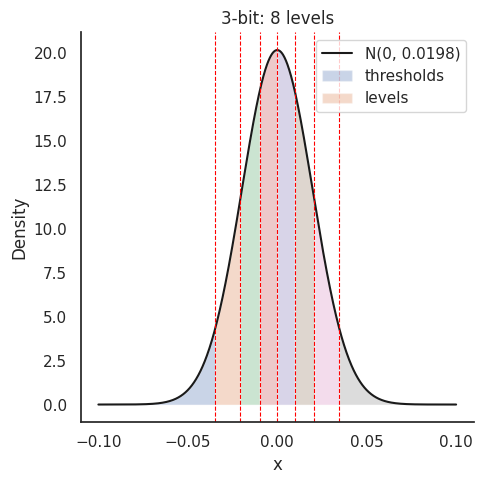

In [59]:
x = np.linspace(-0.1, 0.1, 1000)
pdf = norm.pdf(x, scale=sigma)

fig, ax = plt.subplots(1, 1, figsize=(5, 5), sharex=True)
for idx, bits in enumerate([ 3]):
    n_levels = 2**bits
    t, lv = lloyd_max_gaussian(n_levels, sigma=sigma)
    
    ax.plot(x, pdf, 'k-', lw=1.5)
    # shade each quantization bin with alternating colors
    for i in range(n_levels):
        lo = max(t[i], -0.1)
        hi = min(t[i+1], 0.1)
        mask = (x >= lo) & (x <= hi)
        ax.fill_between(x[mask], pdf[mask], alpha=0.3)
    # mark thresholds
    for ti in t[1:-1]:
        ax.axvline(ti, color='red', ls='--', lw=0.8)
    # mark levels
    # for li in lv:
    #     ax.axvline(li, color='blue', ls='-', lw=1.0, alpha=0.6)
    ax.set_ylabel("Density")
    ax.set_title(f"{bits}-bit: {n_levels} levels")
    ax.legend([f"N(0, {sigma:.4f})", "thresholds", "levels"], loc="upper right")

ax.set_xlabel("x")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()